#Doing Marketing Campaigns Analysis using DS Techniques

In [52]:
#Import the Librarys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported the Module")


Imported the Module


In [53]:
#Load the Data

dataset_path=r"datasets\marketing_data.csv"

df_marketingData=pd.read_csv(dataset_path)

df_marketingData

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,3/7/13,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,1/22/13,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,12/3/12,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,Married,"$65,819.00",0,0,11/29/12,99,267,...,10,3,0,0,0,0,0,0,0,IND


In [54]:
#Dt_Customer and income to verify their accurate importation
#df_marketingData.info()

#Dt_Customer should be of DateTime Type
df_marketingData["Dt_Customer"]=pd.to_datetime(df_marketingData["Dt_Customer"], format='%m/%d/%y', errors='coerce') #Conversion should be based on the data available like it is stored as 11/29/12 means format should be %m/%d/%y

#df_marketingData.info() #Dt_Customer DataType to Dt_Customer 2240 non-null  datetime64[ns]

#Now Move to income column, lets create a new column as Income_Cleaned

df_marketingData["Income_Cleaned"]=df_marketingData[' Income '].str.replace('$','').str.replace(',','').astype(float)

#df_marketingData.info() #income cleaned became float
 

In [55]:
#Some Customers have missing Income_Cleaned Values, Conduct missing value imputation considering that customer with similar education and marital stats tend to have comparable yearly incomes on average

#df_marketingData["Income_Cleaned"].isnull().sum()  #24 rows is having empty income

df_marketingData["Income_Cleaned"]=df_marketingData.groupby(['Education',"Marital_Status"])['Income_Cleaned'].transform(lambda X:X.fillna(X.median()))

df_marketingData["Income_Cleaned"].isnull().sum()  #0 rows is having empty income

#df_marketingData.head()

np.int64(0)

In [56]:
#Create variables to represent the total number of children, age

df_marketingData["Total_Children"]=df_marketingData["Kidhome"] + df_marketingData["Teenhome"]

from datetime import datetime

df_marketingData["Age"]=datetime.now().year-df_marketingData['Year_Birth']

df_marketingData


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income_Cleaned,Total_Children,Age
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,2014-06-16,0,189,...,0,0,0,0,1,0,SP,84835.0,0,56
1,1,1961,Graduation,Single,"$57,091.00",0,0,2014-06-15,0,464,...,0,0,0,1,1,0,CA,57091.0,0,65
2,10476,1958,Graduation,Married,"$67,267.00",0,1,2014-05-13,0,134,...,0,0,0,0,0,0,US,67267.0,1,68
3,1386,1967,Graduation,Together,"$32,474.00",1,1,2014-05-11,0,10,...,0,0,0,0,0,0,AUS,32474.0,2,59
4,5371,1989,Graduation,Single,"$21,474.00",1,0,2014-04-08,0,6,...,0,0,0,0,1,0,SP,21474.0,1,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,"$66,476.00",0,1,2013-03-07,99,372,...,0,0,0,0,0,0,US,66476.0,1,50
2236,5263,1977,2n Cycle,Married,"$31,056.00",1,0,2013-01-22,99,5,...,0,0,0,0,0,0,SP,31056.0,1,49
2237,22,1976,Graduation,Divorced,"$46,310.00",1,0,2012-12-03,99,185,...,0,0,0,0,0,0,SP,46310.0,1,50
2238,528,1978,Graduation,Married,"$65,819.00",0,0,2012-11-29,99,267,...,0,0,0,0,0,0,IND,65819.0,0,48


In [57]:
#total Spending. 

df_marketingData.columns
# total spending.
df_marketingData['Total_Spending']=df_marketingData[['MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds']].sum(axis=1)
df_marketingData['Total_Spending']

0       1190
1        577
2        251
3         11
4         91
        ... 
2235     689
2236      55
2237     309
2238    1383
2239    1078
Name: Total_Spending, Length: 2240, dtype: int64

In [58]:
#total purchases

df_marketingData.columns
df_marketingData["Total_Purchases"]=df_marketingData[['NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases']].sum(axis=1)

df_marketingData["Total_Purchases"]

0       14
1       17
2       10
3        3
4        6
        ..
2235    18
2236     4
2237    12
2238    19
2239    17
Name: Total_Purchases, Length: 2240, dtype: int64

Generate Box Plots and histograms to gain insights into the distributions and identify the outliers and implement outlier treatment as needed

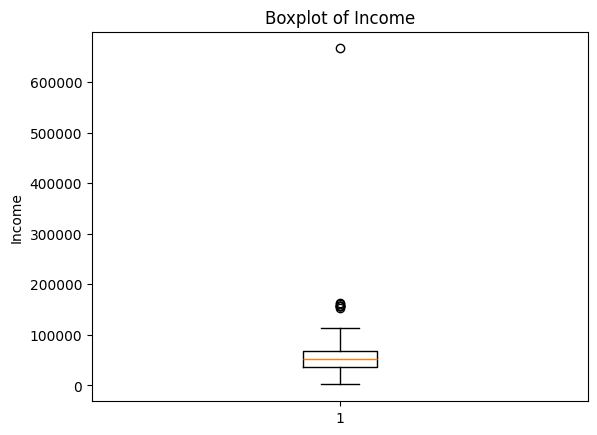

In [59]:
plt.figure()
plt.boxplot(df_marketingData['Income_Cleaned'])
plt.title("Boxplot of Income")
plt.ylabel("Income")
plt.show()

In [60]:
#IQR talks outlies statistically
def detect_outlier(data,column):
  Q1=data[column].quantile(0.25)
  Q3=data[column].quantile(0.75)
  IQR=Q3-Q1
  lower_bound = Q1-1.5*IQR
  upper_bound = Q3+1.5*IQR
  outlier=data[(data[column]>upper_bound) | (data[column]<lower_bound)]
  print(f"Q1 {Q1} Q3 {Q3}")
  print(f"Lower Bound {lower_bound} Upper Bound {upper_bound}")
  print(f'Number of outliers detected in {column}:',len(outlier))
  return outlier
outlier_rows = detect_outlier(df_marketingData,'Income_Cleaned')

Q1 35538.75 Q3 68289.75
Lower Bound -13587.75 Upper Bound 117416.25
Number of outliers detected in Income_Cleaned: 8


In [61]:
outlier_rows=detect_outlier(df_marketingData,"Income_Cleaned")
outlier_rows

Q1 35538.75 Q3 68289.75
Lower Bound -13587.75 Upper Bound 117416.25
Number of outliers detected in Income_Cleaned: 8


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,Income_Cleaned,Total_Children,Age,Total_Spending,Total_Purchases
325,4931,1977,Graduation,Together,"$157,146.00",0,0,2013-04-29,13,1,...,0,0,0,0,SA,157146.0,0,49,1730,28
497,1501,1982,PhD,Married,"$160,803.00",0,0,2012-08-04,21,55,...,0,0,0,0,US,160803.0,0,44,1717,29
527,9432,1977,Graduation,Together,"$666,666.00",1,0,2013-06-02,23,9,...,0,0,0,0,SA,666666.0,1,49,62,7
731,1503,1976,PhD,Together,"$162,397.00",1,1,2013-06-03,31,85,...,0,0,0,0,SP,162397.0,2,50,107,1
853,5336,1971,Master,Together,"$157,733.00",1,0,2013-06-04,37,39,...,0,0,0,0,SP,157733.0,1,55,59,2
1826,5555,1975,Graduation,Divorced,"$153,924.00",0,0,2014-02-07,81,1,...,0,0,0,0,SP,153924.0,0,51,6,0
1925,11181,1949,PhD,Married,"$156,924.00",0,0,2013-08-29,85,2,...,0,0,0,0,CA,156924.0,0,77,8,0
2204,8475,1973,PhD,Married,"$157,243.00",0,1,2014-03-01,98,20,...,0,0,0,0,IND,157243.0,1,53,1608,22


In [62]:
#in typical finance or stock data we go with quantile taking last 1% and remove it
q=df_marketingData["Income_Cleaned"].quantile(0.99)
df_marketingData=df_marketingData[df_marketingData["Income_Cleaned"]<q]
df_marketingData.shape

(2217, 33)

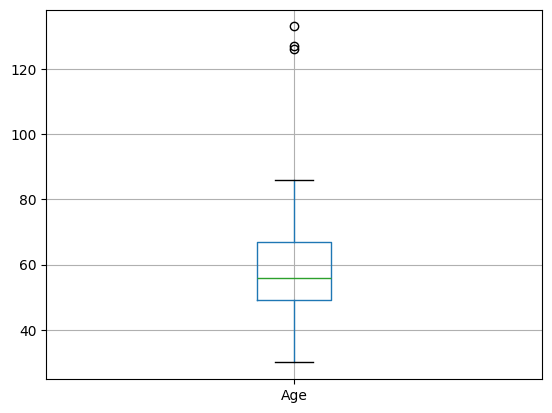

In [63]:
# Create box plot for Age
df_marketingData.boxplot(column='Age')
plt.show()

In [64]:
q=df_marketingData["Age"].quantile(0.99)
print(q)

81.0


(2191, 33)


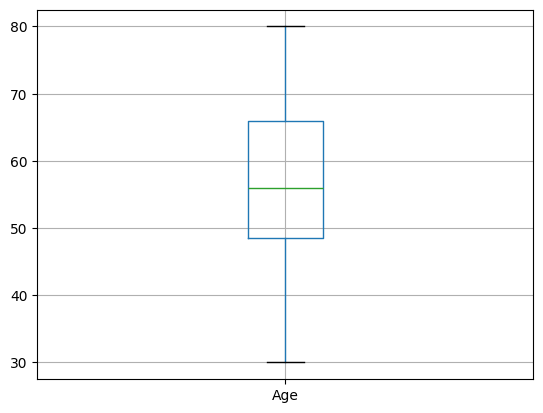

In [65]:
df_marketingData=df_marketingData[df_marketingData["Age"]<q]
print(df_marketingData.shape)

df_marketingData.boxplot(column='Age')
plt.show()

5. Apply Ordinal and one-hot encoding based on the various types of Categorical variables

In [66]:
#check for how many catrgorical variables

df_marketingData.columns #2 categorical variable, 1. Education & another one is Marital_status

df_marketingData["Education"].value_counts(), #Count against Eduction, typical group by

df_marketingData["Education"].unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [67]:
#Categorical Data of Eduction 

education_order=['Basic','2n Cycle','Graduation',  'Master', 'PhD' ]

#Map the Eduction Order

df_marketingData["Education_Encoded"]=df_marketingData["Education"].map({'Basic':0,'2n Cycle':1,'Graduation':2,  'Master':3, 'PhD':4})

df_marketingData["Education_Encoded"]

0       2
1       2
2       2
3       2
4       2
       ..
2234    2
2235    4
2236    1
2237    2
2238    2
Name: Education_Encoded, Length: 2191, dtype: int64

In [68]:
#Categorical Value of Marital_status

df_marketingData["Marital_Status"].value_counts(), #Count against Marital Status, typical group by

df_marketingData["Marital_Status"].unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [69]:
#Apply One Hot Encoding for Marital Status Column

df_marketingData=pd.get_dummies(df_marketingData,columns=["Marital_Status"])

df_marketingData

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Total_Purchases,Education_Encoded,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,1826,1970,Graduation,"$84,835.00",0,0,2014-06-16,0,189,104,...,14,2,False,False,True,False,False,False,False,False
1,1,1961,Graduation,"$57,091.00",0,0,2014-06-15,0,464,5,...,17,2,False,False,False,False,True,False,False,False
2,10476,1958,Graduation,"$67,267.00",0,1,2014-05-13,0,134,11,...,10,2,False,False,False,True,False,False,False,False
3,1386,1967,Graduation,"$32,474.00",1,1,2014-05-11,0,10,0,...,3,2,False,False,False,False,False,True,False,False
4,5371,1989,Graduation,"$21,474.00",1,0,2014-04-08,0,6,16,...,6,2,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2234,9977,1973,Graduation,"$78,901.00",0,1,2013-09-17,99,321,11,...,17,2,False,False,True,False,False,False,False,False
2235,10142,1976,PhD,"$66,476.00",0,1,2013-03-07,99,372,18,...,18,4,False,False,True,False,False,False,False,False
2236,5263,1977,2n Cycle,"$31,056.00",1,0,2013-01-22,99,5,10,...,4,1,False,False,False,True,False,False,False,False
2237,22,1976,Graduation,"$46,310.00",1,0,2012-12-03,99,185,2,...,12,2,False,False,True,False,False,False,False,False


Text(0.5, 1.0, 'Correlation Heatmap')

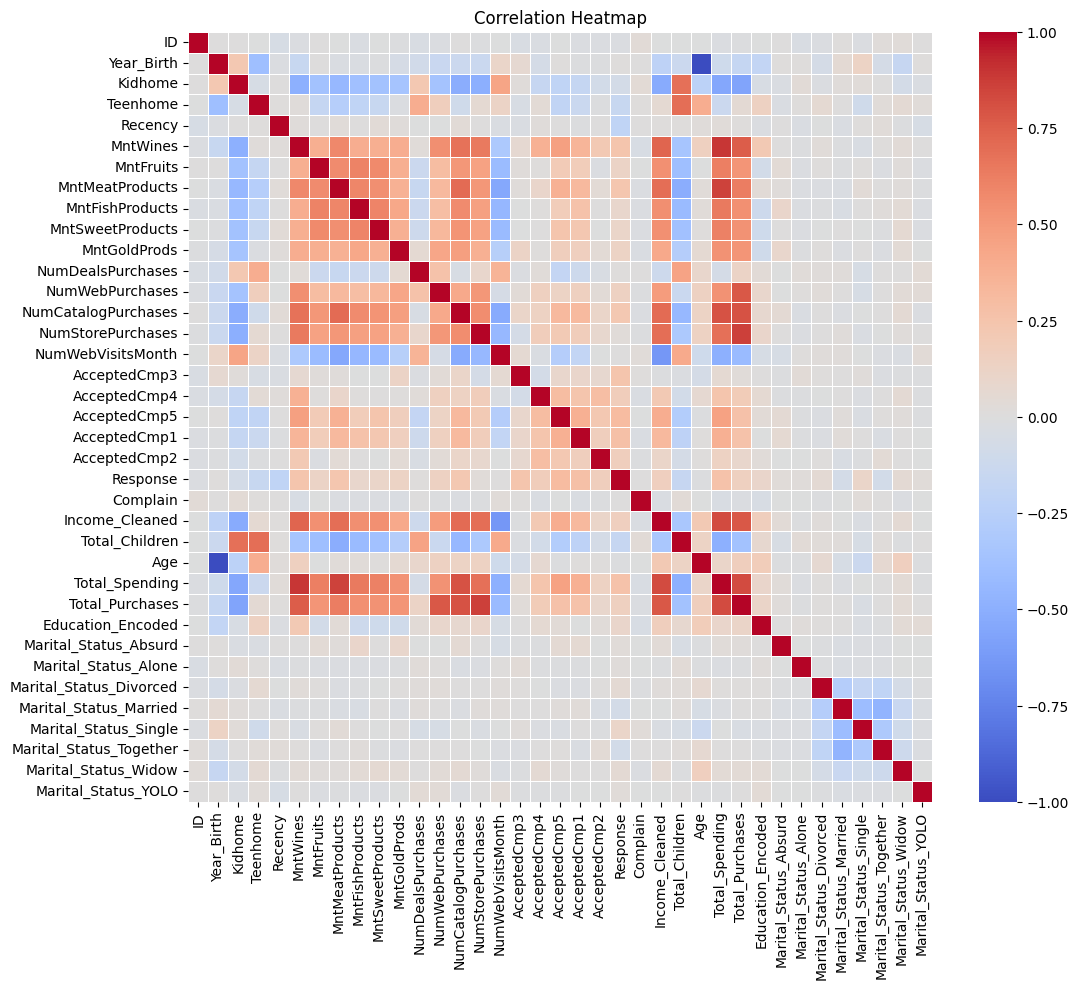

In [70]:
#Generate the Heat map to illustrate the correlation between different pairs of variables
plt.figure(figsize=(12,10)) #to increase the size of the heatmap, figsize is used to specify the size of the figure in inches, where (12,10) means 12 inches wide and 10 inches tall.
sns.heatmap(df_marketingData.corr(numeric_only=True), cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')

#Test the Hypothesis

a. Older Individuals may not possess the same level of tech proficiency  and may lean toward traditional in-store shopping preferences


In [76]:
#Test the Hypothesis 1. Older Individuals may not possess the same level of tech proficiency  and may lean toward traditional in-store shopping preferences
#H0= There is no significant difference in store purchase behavior between older and young individuals, null hypothesis 

    #Pearson Correlation p_value to test the correlation between Age and Total_Purchases

#H1= There is a significant difference in store purchase behavior between older and young individuals, alternative hypothesis

from scipy.stats import pearsonr
correlation, p_value = pearsonr(df_marketingData['Age'], df_marketingData['NumStorePurchases'])
print(f"Pearson Correlation Coefficient: {correlation}")
print(f"P-value: {p_value}")

#p_value is less than 0.05, we reject the null hypothesis and accept the alternative hypothesis, which suggests that there is a significant difference in store purchase behavior between older and young individuals. The negative correlation coefficient indicates that as age increases, the number of store purchases tends to decrease, supporting the idea that older individuals may prefer traditional in-store shopping less than younger individuals.

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in store purchase behavior between older and young individuals.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in store purchase behavior between older and young individuals.")
    

Pearson Correlation Coefficient: 0.1346958887018676
P-value: 2.4495536738696183e-10
Reject the null hypothesis: There is a significant difference in store purchase behavior between older and young individuals.


b. Customer with children likely experience time constraints, making online shopping a more convenient option


In [80]:
#H0- There is no significate difference in online shopping behaviour between customer with children and without children ---- null hypothesis
#H0- There is significate difference in online shopping behaviour between customer with children and without children ---- alternate hypothesis
#Create 2 group, Group 1 with customer with Web Purchases and Group 2 with customer without Web purchases

#create a new column to categorize customers based on whether they have children or not
df_marketingData["Has_Children"]=df_marketingData["Total_Children"]>0

webpurchases_with_children=df_marketingData[df_marketingData["Has_Children"]==True]["NumWebPurchases"]
webpurchases_without_children=df_marketingData[df_marketingData["Has_Children"]==False]["NumWebPurchases"]

#print(webpurchases_with_children)
#print(webpurchases_without_children)

#Perform an independent t-test to compare the means of the two groups
from scipy.stats import ttest_ind
t_statistic, p_value = ttest_ind(webpurchases_with_children, webpurchases_without_children)
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in online shopping behavior between customers with children and without children.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in online shopping behavior between customers with children and without children.")

T-statistic: -2.534580199450869
P-value: 0.011327355906544235
Reject the null hypothesis: There is a significant difference in online shopping behavior between customers with children and without children.


C. Sales at Physical stores may face the risk of cannibalization by alternative distribution channels


In [81]:
# Sales at Physical stores may face the risk of cannibalization by alternative distribution channels
    #H0- There is no significant relationship between store purchase and online purchases, null hypothesis
    #H1- There is a significant relationship between store purchase and online purchases, alternative hypothesis

from scipy.stats import pearsonr
correlation, p_value = pearsonr(df_marketingData['NumStorePurchases'], df_marketingData['NumWebPurchases'])
print(f"Pearson Correlation Coefficient: {correlation}")
print(f"P-value: {p_value}")

#p_value is less than 0.05, we reject the null hypothesis and accept the alternative hypothesis, which suggests that there is a significant relationship between store purchases and online purchases. The negative correlation coefficient indicates that as store purchases increase, the number of web purchases tends to decrease, supporting the idea that customers who shop more in physical stores may be less likely to shop online.

if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant relationship between store purchase and online purchases.")
else:
    print("Fail to reject the null hypothesis: There is no significant relationship between store purchase and online purchases.")

Pearson Correlation Coefficient: 0.514696428122338
P-value: 1.6896669543298397e-148
Reject the null hypothesis: There is a significant relationship between store purchase and online purchases.


d. Does the United States significantly outperform the reset of the worlds in total purchase volumes


In [86]:
#d. Does the United States significantly outperform the reset of the worlds in total purchase volumes
#H0- Mean total purchase volumes for customers from the United States is equal to the mean total purchase volumes for customers from the rest of the world, null hypothesis
#H1- Mean total purchase volumes for customers from the United States is significantly different from the mean total purchase volumes for customers from the rest of the world, alternative hypothesis

#print(df_marketingData["Country"].value_counts())

import scipy.stats as stats
#Create two groups, Group 1 with customers from the United States and Group 2 with customers from the rest of the world
us_customers=df_marketingData[df_marketingData["Country"]=="US"]["Total_Purchases"]
rest_of_world_customers=df_marketingData[df_marketingData["Country"]!="US"]["Total_Purchases"]

#print(us_customers)
#print(rest_of_world_customers)

#Perform an independent t-test to compare the means of the two groups
t_statistic, p_value = stats.ttest_ind(us_customers, rest_of_world_customers)
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

if p_value < 0.05:
    print("Reject the null hypothesis: Mean total purchase volumes for customers from the United States is significantly different from the mean total purchase volumes for customers from the rest of the world.") 
else:
    print("Fail to reject the null hypothesis: Mean total purchase volumes for customers from the United States is equal to the mean total purchase volumes for customers from the rest of the world.")

T-statistic: 1.4158249639925495
P-value: 0.15696902203833465
Fail to reject the null hypothesis: Mean total purchase volumes for customers from the United States is equal to the mean total purchase volumes for customers from the rest of the world.


#Use Appropriate visualization to help analyze the following

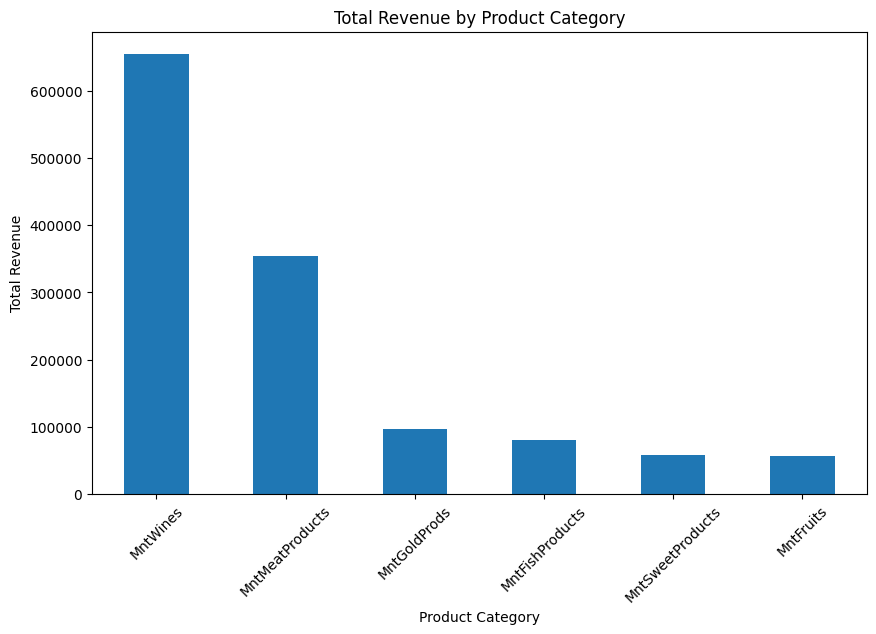

In [87]:
#a. Identify the top-performing products and those with lowest revenues
#Calculate the total revenue for each product category by multiplying the quantity purchased by the price of each product and summing it up for all customers. Then, we can rank the products based on their total revenue to identify the top-performing and lowest-performing products.
product_columns=['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
product_revenues=df_marketingData[product_columns].sum()
#sort the products based on total revenue
product_revenues_sorted=product_revenues.sort_values(ascending=False)
#Plot a bar chart to visualize the total revenue for each product category
plt.figure(figsize=(10,6))
product_revenues_sorted.plot(kind='bar')
plt.title('Total Revenue by Product Category')  
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


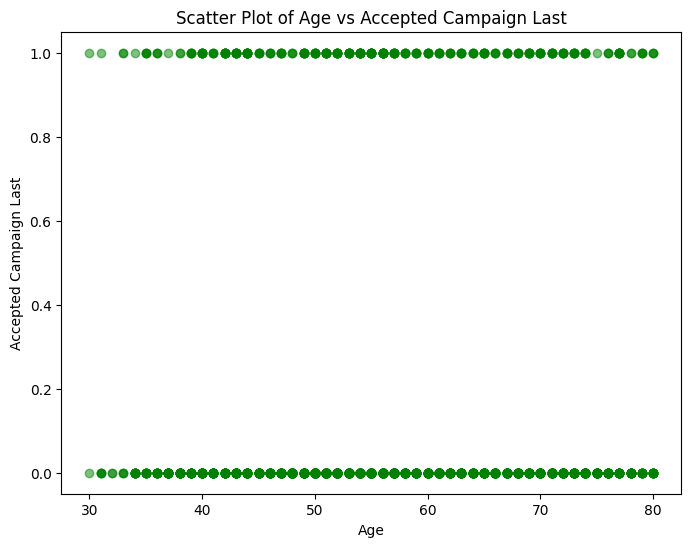

Correlation between Age and Accepted Campaign Last:                Age  Response
Age       1.000000 -0.015419
Response -0.015419  1.000000


In [95]:
#b.Examine if there is a correlation between customers age and the acceotance rate of the last campaign.

#scatter plot to visualize the relationship between Age and AcceptedCmpLastCampaign
plt.figure(figsize=(8,6))
plt.scatter(df_marketingData['Age'], df_marketingData['Response'], alpha=0.5, color='green')
plt.xlabel('Age')
plt.ylabel('Accepted Campaign Last')
plt.title('Scatter Plot of Age vs Accepted Campaign Last')
plt.show()
#Calculate the Correlation.
correlation=df_marketingData[['Age','Response']].corr()
print(f"Correlation between Age and Accepted Campaign Last: {correlation}")

Country
SP     169
SA      48
CA      36
AUS     20
GER     17
IND     13
US      13
ME       2
Name: Response, dtype: int64


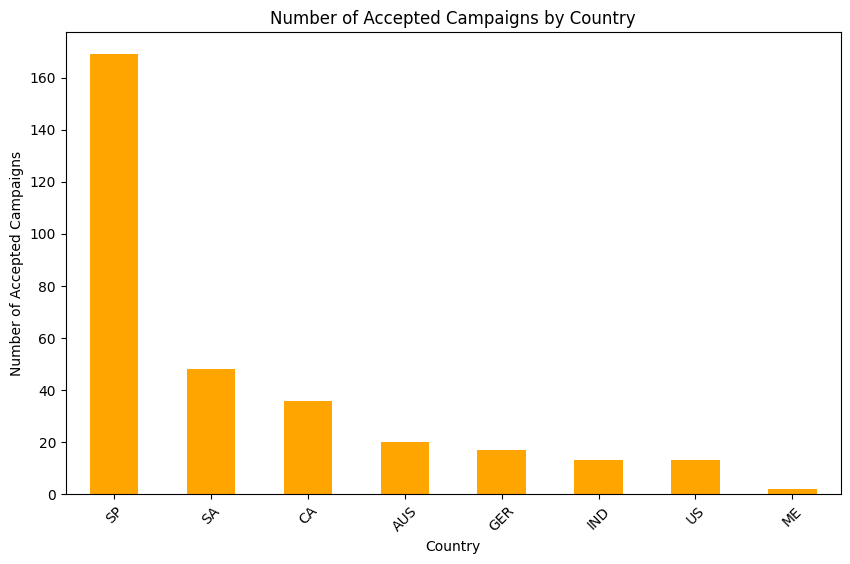

In [ ]:
#Determine the country with the hiughest number of last campaigns
accepted_campaigns_by_country=df_marketingData.groupby('Country')['Response'].sum().sort_values(ascending=False)
print(accepted_campaigns_by_country)
accepted_campaigns_by_country.plot(kind='bar', figsize=(10,6), color='orange')
plt.title('Number of Accepted Campaigns by Country')
plt.xlabel('Country')
plt.ylabel('Number of Accepted Campaigns')
plt.xticks(rotation=45)
plt.show()

Country
SP     72
SA     18
CA     17
GER     7
US      7
IND     7
AUS     6
ME      0
Name: AcceptedCmp1, dtype: int64


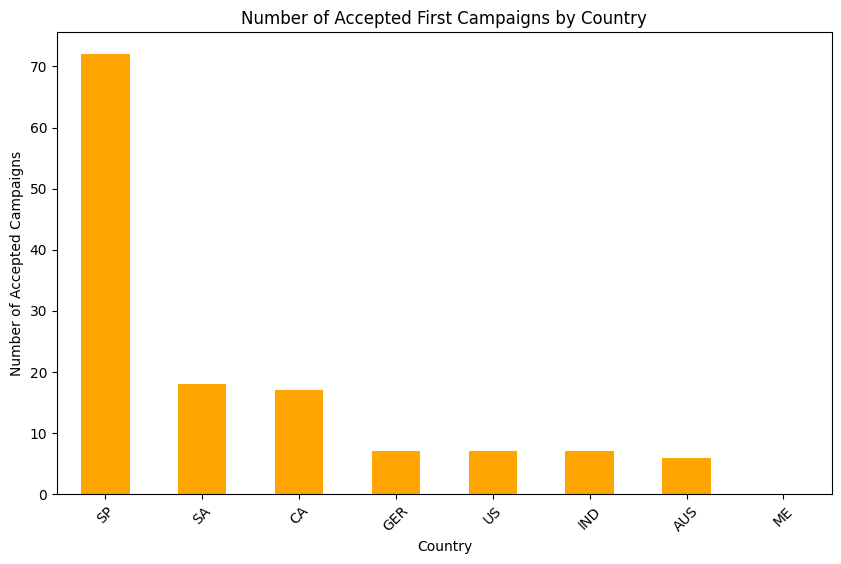

In [99]:
#Determine the country with the hiughest number of first campaigns
accepted_campaigns_by_country=df_marketingData.groupby('Country')['AcceptedCmp1'].sum().sort_values(ascending=False)
print(accepted_campaigns_by_country)
accepted_campaigns_by_country.plot(kind='bar', figsize=(10,6), color='orange')
plt.title('Number of Accepted First Campaigns by Country')
plt.xlabel('Country')
plt.ylabel('Number of Accepted Campaigns')
plt.xticks(rotation=45)
plt.show()

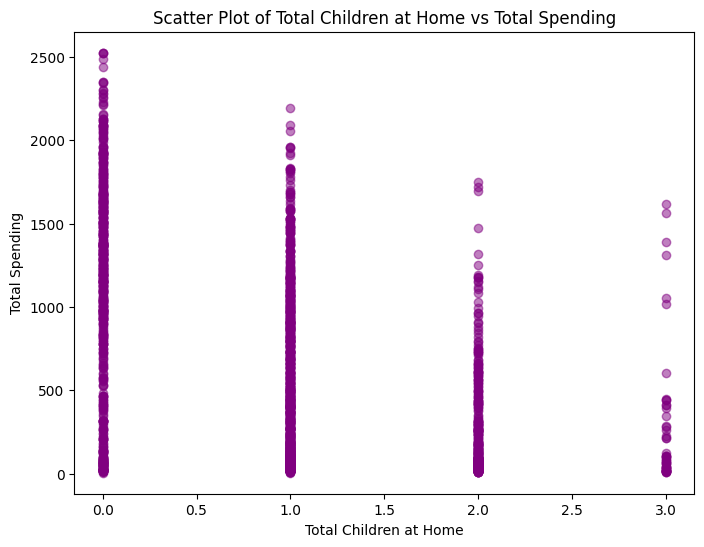

Correlation between Total Children at Home and Total Spending:                 Total_Children  Total_Spending
Total_Children         1.00000        -0.49281
Total_Spending        -0.49281         1.00000
Completed the Analysis


In [101]:
#d. Investigate if there is a discernible pattern in the number of childer at home and the total expenditure
plt.figure(figsize=(8,6))
plt.scatter(df_marketingData['Total_Children'], df_marketingData['Total_Spending'], alpha=0.5, color='purple')
plt.xlabel('Total Children at Home')    
plt.ylabel('Total Spending')
plt.title('Scatter Plot of Total Children at Home vs Total Spending')
plt.show()
#Calculate the Correlation.
correlation=df_marketingData[['Total_Children','Total_Spending']].corr()
print(f"Correlation between Total Children at Home and Total Spending: {correlation}")
print("Completed the Analysis")

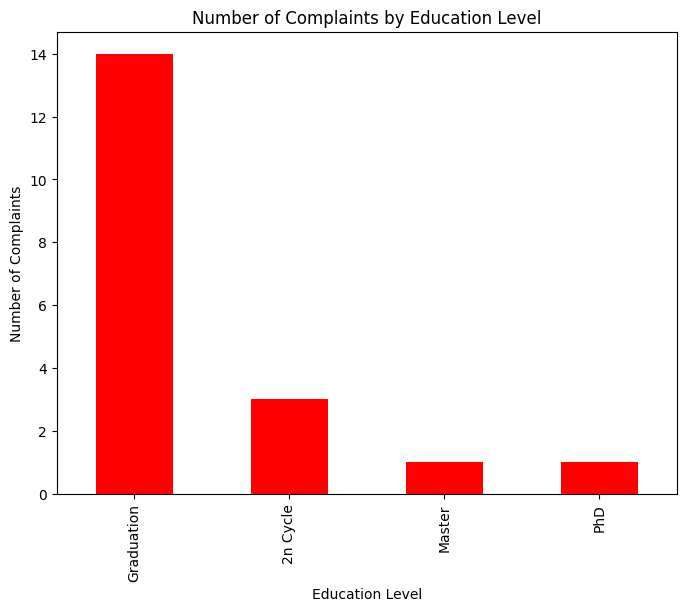

In [102]:
#e.Analyse the education background of customers who lodged compliants in the last two years, visualization

complaints_by_education=df_marketingData[df_marketingData["Complain"]>0]["Education"].value_counts()
plt.figure(figsize=(8,6))
complaints_by_education.plot(kind='bar', color='red')
plt.title('Number of Complaints by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Complaints')
plt.show()